# Hurricane Damage Detection: Inference Demo

## Table of Contents
- [1. How to Run & Setup](#1-how-to-run--setup)
- [3. Data & Artifacts: Original Dataset vs. Resampled Dataset](#3-data--artifacts-original-dataset-vs-resampled-dataset)
- [4. "Time-Detector" Evaluation (Leakage Probe)](#4-time-detector-evaluation-leakage-probe)
- [5. "Time Detector" Grad-CAMs](#5-time-detector-grad-cams)
- [6. Grad-CAM: CNN Baselines (ConvNeXt/ResNet)](#6-grad-cam-cnn-baselines-convnextresnet)
- [7. Hyperparameter-Tuned ResNet34 (resampled)](#7-hyperparameter-tuned-resnet34-resampled)

## 1. How to Run & Setup
1. Create environment (CPU-first): `conda env create -f inference/environment.yml && conda activate hurricane-inference`.
2. Open this notebook from the repo root so relative paths resolve.
3. Run cells in order; Google drive folder includes checkpoints and zipped data (original + resampled).

This cell initializes paths, seeds, and plotting defaults so later computations reproduce the report’s inference conditions on CPU or GPU. The environment.yml mirrors the report’s dependency stack; executing cells sequentially preserves the expected relative paths.

In [1]:
# Imports and paths
from __future__ import annotations
import random, sys, zipfile
from pathlib import Path
from typing import Dict, List, Optional

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Resolve project root and enable src/ imports regardless of launch dir
if "__file__" in globals():
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
else:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd if (cwd / "inference").exists() else cwd.parent
sys.path.append(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from config import TrainConfig
from data.transforms import build_transforms
from utils.checkpoint import load_checkpoint
from validation.calibration import TemperatureScaler
from validation.evaluate import evaluate

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 200

# Resolve key directories and device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INFERENCE_DIR = PROJECT_ROOT / "inference"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
DATA_DIR = PROJECT_ROOT / "data"
RESAMPLED_DIR = PROJECT_ROOT / "data_resampled"
for path in [ARTIFACTS_DIR, DATA_DIR, RESAMPLED_DIR]:
    path.mkdir(parents=True, exist_ok=True)
print(f"Using device: {device}")

def set_seed(seed: int = 42) -> None:
    """Set all relevant seeds for reproducibility across CPU/GPU."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(42)

Using device: cpu


In [2]:
# Download artifacts + datasets from Google Drive
GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1fFiyF_eVUCPRggc8Ti4RAl3zCMj8vAhL?usp=sharing"

# Files expected after a successful download. If all exist, the download step is skipped.
EXPECTED_ARTIFACTS = [
    ARTIFACTS_DIR / "data.zip",
    ARTIFACTS_DIR / "data_resampled.zip",
    ARTIFACTS_DIR / "time_detector_base.pt",
    ARTIFACTS_DIR / "time_detector_shuffle.pt",
    ARTIFACTS_DIR / "time_detector_resampled.pt",
    ARTIFACTS_DIR / "convnext_tiny-data.pt",
    ARTIFACTS_DIR / "resnet34-resampled.pt",
    ARTIFACTS_DIR / "resnet50-resampled.pt",
    ARTIFACTS_DIR / "resnet34-hp-tuned.pt",
]

def find_missing(paths: List[Path]) -> List[Path]:
    """Return any paths from the list that are not present on disk."""
    return [p for p in paths if not p.exists()]

def download_from_drive(url: str, out_dir: Path) -> None:
    """Fetch the shared Drive folder and place contents under out_dir."""
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"Downloading folder {url} -> {out_dir}")
    gdown.download_folder(url=url, output=str(out_dir), quiet=False, use_cookies=False, remaining_ok=True)

def unzip_archives(search_root: Path, dest: Path) -> None:
    """Unzip every .zip found under search_root into dest."""
    zips = list(search_root.rglob("*.zip"))
    if not zips:
        print(f"No zip archives found in {search_root}")
        return
    dest.mkdir(parents=True, exist_ok=True)
    for archive in zips:
        print(f"Extracting {archive.name} -> {dest}")
        with zipfile.ZipFile(archive, "r") as zf:
            zf.extractall(dest)

def move_split_dirs(src_root: Path, dest_root: Path) -> None:
    """Relocate train/validation/test folders into the desired dest_root."""
    for split in ["train", "validation", "test"]:
        src = src_root / split
        dest = dest_root / split
        if src.exists() and not dest.exists():
            dest_root.mkdir(parents=True, exist_ok=True)
            print(f"Moving {src} -> {dest}")
            src.rename(dest)

# Ensure artifacts and data are present (original and resampled datasets)
missing_artifacts = find_missing(EXPECTED_ARTIFACTS)
if missing_artifacts:
    print("Missing artifacts detected; downloading:")
    for p in missing_artifacts:
        print(f" - {p.name}")
    download_from_drive(GDRIVE_FOLDER_URL, ARTIFACTS_DIR)
    missing_artifacts = find_missing(EXPECTED_ARTIFACTS)
    if missing_artifacts:
        raise FileNotFoundError(f"Artifacts still missing after download: {[p.name for p in missing_artifacts]}")
else:
    print("All expected artifacts present; skipping download.")

original_ready = (DATA_DIR / "train").exists() and (DATA_DIR / "validation").exists() and (DATA_DIR / "test").exists()
resampled_ready = (RESAMPLED_DIR / "train").exists() and (RESAMPLED_DIR / "validation").exists() and (RESAMPLED_DIR / "test").exists()

if not (original_ready and resampled_ready):
    unzip_archives(ARTIFACTS_DIR, PROJECT_ROOT)

    # Fix cases where splits were extracted in the wrong place
    move_split_dirs(PROJECT_ROOT, DATA_DIR)
    move_split_dirs(PROJECT_ROOT / "data", DATA_DIR)
    move_split_dirs(PROJECT_ROOT / "data_resampled", RESAMPLED_DIR)
    move_split_dirs(PROJECT_ROOT, RESAMPLED_DIR)
    original_ready = (DATA_DIR / "train").exists() and (DATA_DIR / "validation").exists() and (DATA_DIR / "test").exists()
    resampled_ready = (RESAMPLED_DIR / "train").exists() and (RESAMPLED_DIR / "validation").exists() and (RESAMPLED_DIR / "test").exists()

print(f"Original dataset present: {original_ready} | Resampled dataset present: {resampled_ready}")
print(f"Artifact contents: {list(ARTIFACTS_DIR.iterdir())}")
if not (original_ready and resampled_ready):
    raise FileNotFoundError("Expected data/ and data_resampled/ with train/validation/test splits under the repo root. Ensure data.zip is downloaded and rerun this cell.")

Missing artifacts detected; downloading:
 - data.zip
 - data_resampled.zip
 - time_detector_base.pt
 - time_detector_shuffle.pt
 - time_detector_resampled.pt
 - convnext_tiny-data.pt
 - resnet34-resampled.pt
 - resnet50-resampled.pt
 - resnet34-hp-tuned.pt


Retrieving folder contents


Processing file 1Oyjz5RdbDeQGxuCMDB_r_gfX8sM3L8yo convnext_tiny-data.pt
Processing file 1i88SrPLghnQRI6vUvfEbDPPXlbxXdKYw data_resampled.zip
Processing file 1vWwI8c0tx1DEq9fjeTU53inhhoVmoDYN data.zip
Processing file 17hrjItS3hiCTizpoidqmX_JuLfjHHaQX resnet34-hp-tuned.pt
Processing file 1qPeqhGOTBG7IUzMun2SfeylLVP7hpdm2 resnet34-resampled.pt
Processing file 1RM23PtxtV7bdebtc7hbRt0WbXy-YNCvZ resnet50-resampled.pt
Processing file 1E3A_6Rb1W1Mz-jDr2idKehGx2m_S7Fkx time_detector_base.pt
Processing file 1muD9RoUCxDM-KAXaDTSwOlLa5fcb9Q9K time_detector_resampled.pt
Processing file 1ECaHAMktLrdxGNJHvSYgaaj66JBIHNoB time_detector_shuffle.pt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1Oyjz5RdbDeQGxuCMDB_r_gfX8sM3L8yo
From (redirected): https://drive.google.com/uc?id=1Oyjz5RdbDeQGxuCMDB_r_gfX8sM3L8yo&confirm=t&uuid=4210c873-cdb8-4a15-a90d-50976666e22a
To: /home/tim/test/ipeo-hurricane-damage-detection/artifacts/convnext_tiny-data.pt
100%|██████████| 111M/111M [00:00<00:00, 151MB/s]  
Downloading...
From (original): https://drive.google.com/uc?id=1i88SrPLghnQRI6vUvfEbDPPXlbxXdKYw
From (redirected): https://drive.google.com/uc?id=1i88SrPLghnQRI6vUvfEbDPPXlbxXdKYw&confirm=t&uuid=49dccb41-de84-47f7-b05a-44be64906126
To: /home/tim/test/ipeo-hurricane-damage-detection/artifacts/data_resampled.zip
100%|██████████| 253M/253M [00:01<00:00, 205MB/s]  
Downloading...
From (original): https://drive.google.com/uc?id=1vWwI8c0tx1DEq9fjeTU53inhhoVmoDYN
From (redirected): https://drive.google.com/uc?id=1vWwI8c0tx1DEq9

Extracting data_resampled.zip -> /home/tim/test/ipeo-hurricane-damage-detection
Extracting data.zip -> /home/tim/test/ipeo-hurricane-damage-detection
Moving /home/tim/test/ipeo-hurricane-damage-detection/train -> /home/tim/test/ipeo-hurricane-damage-detection/data/train
Moving /home/tim/test/ipeo-hurricane-damage-detection/validation -> /home/tim/test/ipeo-hurricane-damage-detection/data/validation
Moving /home/tim/test/ipeo-hurricane-damage-detection/test -> /home/tim/test/ipeo-hurricane-damage-detection/data/test
Original dataset present: True | Resampled dataset present: True
Artifact contents: [PosixPath('/home/tim/test/ipeo-hurricane-damage-detection/artifacts/time_detector_resampled.pt'), PosixPath('/home/tim/test/ipeo-hurricane-damage-detection/artifacts/resnet34-hp-tuned.pt'), PosixPath('/home/tim/test/ipeo-hurricane-damage-detection/artifacts/convnext_tiny-data.pt'), PosixPath('/home/tim/test/ipeo-hurricane-damage-detection/artifacts/resnet50-resampled.pt'), PosixPath('/home/t

## 3. Data & Artifacts: Original Dataset vs. Resampled Dataset
- In `data/` the original dataset is stored; resampled `data_resampled/` is the block-based, keep-one-per-coordinate protocol (Report Section 2.3).
- After resampling: 14'223 images (Train 12','600 | Val 495 | Test 1'128); exact-coordinate leakage removed, cross-split near-neighbors drop to 29 pairs within 50 m (Report Table 3.1).
- Class labels remain temporally confounded (damage=post, no_damage=pre); resampling mainly removes spatial shortcuts, not photometric ones.

In [3]:
# Helper utilities: path resolution, loading checkpoints, evaluation
# Shared plotting defaults keep all figures aligned in size and DPI.
PLOT_DPI = 200
METRIC_FIGSIZE = (12, 4.2)
CAM_FIGSIZE_TRIPLE = (12, 4.2)
CAM_FIGSIZE_HP = (13, 4.2)

def prefer(primary: Path, fallback: Path) -> Path:
    """Pick primary if it exists, otherwise fallback."""
    return primary if primary.exists() else fallback

DATA_ROOT = prefer(DATA_DIR, PROJECT_ROOT / "data")
RESAMPLED_ROOT = prefer(RESAMPLED_DIR, PROJECT_ROOT / "data_resampled")

def load_model_bundle(label: str, ckpt_path: Path, temp_path: Optional[Path], data_root: Path):
    """Load a model checkpoint plus optional temperature scaler."""
    ckpt_path = ckpt_path.expanduser()
    assert ckpt_path.exists(), f"Missing checkpoint for {label}: {ckpt_path}"
    model, cfg = load_checkpoint(str(ckpt_path), map_location=device)
    cfg.pretrained = False
    cfg.data_root = str(data_root)
    model = model.to(device)
    model.eval()
    temperature = TemperatureScaler.load(str(temp_path), device=device) if temp_path and temp_path.exists() else None
    return model, cfg, temperature

def build_eval_loaders(cfg: TrainConfig):
    """Create val/test DataLoaders with the eval transforms from the saved config."""
    root = Path(cfg.data_root).expanduser()
    root = root if root.is_absolute() else PROJECT_ROOT / root
    tfm = build_transforms(cfg, train=False)
    val_ds = ImageFolder(root / "validation", transform=tfm)
    test_ds = ImageFolder(root / "test", transform=tfm)
    def loader(ds):
        return DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
    return loader(val_ds), loader(test_ds)

def evaluate_model(label: str, ckpt_path: Path, temp_path: Optional[Path], data_root: Path) -> pd.DataFrame:
    """Run eval on validation and test splits and return a tidy DataFrame."""
    model, cfg, temperature = load_model_bundle(label, ckpt_path, temp_path, data_root)
    val_loader, test_loader = build_eval_loaders(cfg)
    val_metrics, _ = evaluate(model, val_loader, device, cfg, temperature=temperature)
    test_metrics, _ = evaluate(model, test_loader, device, cfg, temperature=temperature)
    rows = [
        {"model": label, "split": "validation", **val_metrics},
        {"model": label, "split": "test", **test_metrics},
    ]
    return pd.DataFrame(rows)

def _annotate_bars(ax):
    """Write numeric values above bars; skip zeros to avoid clutter."""
    for patch in ax.patches:
        height = patch.get_height()
        if height <= 1e-3:
            continue
        ax.text(patch.get_x() + patch.get_width()/2, height + 0.01, f"{height:.2f}", ha="center", va="bottom", fontsize=9)

def plot_metric_table(df: pd.DataFrame, title: str) -> None:
    """Display metrics table and aligned bar plots for validation vs test."""
    display(df.round(4))
    metrics = [c for c in ["accuracy", "macro_precision", "macro_recall", "macro_f1", "ece"] if c in df.columns]
    fig, axes = plt.subplots(1, 2, figsize=METRIC_FIGSIZE, dpi=PLOT_DPI, sharey=True)
    legend_handles, legend_labels = None, None
    for ax, split in zip(axes, ["validation", "test"]):
        subset = df[df["split"] == split]
        tidy = subset.melt(id_vars=["model", "split"], value_vars=metrics, var_name="metric", value_name="value")
        sns.barplot(data=tidy, x="metric", y="value", hue="model", ax=ax, edgecolor="black")
        _annotate_bars(ax)
        subtitle = "Evaluated on Validation Split" if split == "validation" else "Evaluated on Test Split"
        ax.set_title(subtitle)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("metric")
        ax.set_ylabel("value" if ax is axes[0] else "")
        plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
        handles, labels = ax.get_legend_handles_labels()
        if handles and labels and legend_handles is None:
            legend_handles, legend_labels = handles, labels
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    if legend_handles:
        fig.legend(legend_handles, legend_labels, title="model", loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=len(legend_labels))
    fig.suptitle(title, y=1.12)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


In [4]:
# Model registry with fallbacks to local training_runs if Drive artifacts are absent
# Ties to report: time_* entries reproduce the spectral/temporal shortcut probe (Section 3.2);
# other backbones correspond to the model zoo and the ResNet-34 hyperparameter search (Section 4.5).

RUNS: Dict[str, Dict] = {
    "time_base": {
        "label": "Base",
        "ckpt": prefer(ARTIFACTS_DIR / "time_detector_base.pt", PROJECT_ROOT / "training_runs/time_detector_base/checkpoints/best.pt"),
        "temp": None,
        "data_root": DATA_ROOT,
    },
    "time_shuffle": {
        "label": "Shuffle",
        "ckpt": prefer(ARTIFACTS_DIR / "time_detector_shuffle.pt", PROJECT_ROOT / "training_runs/time_detector_shuffle/checkpoints/best.pt"),
        "temp": None,
        "data_root": DATA_ROOT,
    },
    "time_resampled": {
        "label": "Resampled",
        "ckpt": prefer(ARTIFACTS_DIR / "time_detector_resampled.pt", PROJECT_ROOT / "training_runs/time_detector_resampled/checkpoints/best.pt"),
        "temp": None,
        "data_root": RESAMPLED_ROOT,
    },
    "convnext_tiny_data": {
        "label": "ConvNeXt-Tiny (original)",
        "ckpt": prefer(ARTIFACTS_DIR / "convnext_tiny-data.pt", PROJECT_ROOT / "training_runs/data_2025_12_11-22_35_convnext_tiny/artifacts/checkpoints/best.pt"),
        "temp": None,
        "data_root": DATA_ROOT,
    },
    "resnet34_resampled": {
        "label": "ResNet34 (resampled)",
        "ckpt": prefer(ARTIFACTS_DIR / "resnet34-resampled.pt", PROJECT_ROOT / "training_runs/data_resampled_2025_12_11-22_35_resnet34/artifacts/checkpoints/best.pt"),
        "temp": None,
        "data_root": RESAMPLED_ROOT,
    },
    "resnet50_resampled": {
        "label": "ResNet50 (resampled)",
        "ckpt": prefer(ARTIFACTS_DIR / "resnet50-resampled.pt", PROJECT_ROOT / "training_runs/data_resampled_2025_12_11-22_35_resnet50/artifacts/checkpoints/best.pt"),
        "temp": None,
        "data_root": RESAMPLED_ROOT,
    },
    "resnet34_hp": {
        "label": "ResNet34 (hp-tuned)",
        "ckpt": prefer(ARTIFACTS_DIR / "resnet34-hp-tuned.pt", PROJECT_ROOT / "training_runs/hyperparam_data_resampled_resnet34_20251212-041834/t027_resnet34_lr2.36e-04_wd5.17e-05_do0p16_bs48_img256_s42/artifacts/checkpoints/best.pt"),
        "temp": None,
        "data_root": RESAMPLED_ROOT,
    },
}

# Log which checkpoints/temps are found to aid debugging missing files
for key, spec in RUNS.items():
    print(f"{key}: ckpt={spec['ckpt']} | temp={spec['temp']} | data_root={spec['data_root']}")


time_base: ckpt=/home/tim/test/ipeo-hurricane-damage-detection/artifacts/time_detector_base.pt | temp=None | data_root=/home/tim/test/ipeo-hurricane-damage-detection/data
time_shuffle: ckpt=/home/tim/test/ipeo-hurricane-damage-detection/artifacts/time_detector_shuffle.pt | temp=None | data_root=/home/tim/test/ipeo-hurricane-damage-detection/data
time_resampled: ckpt=/home/tim/test/ipeo-hurricane-damage-detection/artifacts/time_detector_resampled.pt | temp=None | data_root=/home/tim/test/ipeo-hurricane-damage-detection/data_resampled
convnext_tiny_data: ckpt=/home/tim/test/ipeo-hurricane-damage-detection/artifacts/convnext_tiny-data.pt | temp=None | data_root=/home/tim/test/ipeo-hurricane-damage-detection/data
resnet34_resampled: ckpt=/home/tim/test/ipeo-hurricane-damage-detection/artifacts/resnet34-resampled.pt | temp=None | data_root=/home/tim/test/ipeo-hurricane-damage-detection/data_resampled
resnet50_resampled: ckpt=/home/tim/test/ipeo-hurricane-damage-detection/artifacts/resnet50-

The model registry maps each model to its checkpoint and data root. Time-detector entries (Base, Shuffle, Resampled) reproduce the leakage probe in Report Section 3.2; ConvNeXt-Tiny and ResNet34/50 correspond to the model zoo comparisons; the HP-tuned ResNet34 reflects the hyperparameter tuning from Section 4.5.

## 4. "Time-Detector" Evaluation (Leakage Probe)

### How the variants differ
- **Base**: trained on the original dataset; exploits time-gap signal.
- **Shuffle**: pixels shuffled within images to destroy spatial structure while keeping global appearance; probes reliance on spectral shortcuts.
- **Resampled**: trained on geo-balanced resampled split to reduce location/appearance skew.

,model,split,accuracy,macro_precision,macro_recall,macro_f1,brier,ece
0,Base,validation,0.8870,0.8982,0.8870,0.8862,0.0876,0.0241
1,Base,test,0.8865,0.8990,0.8865,0.8856,0.0925,0.0284
2,Shuffle,validation,0.7810,0.7812,0.7810,0.7810,0.1618,0.0899
3,Shuffle,test,0.7795,0.7796,0.7795,0.7795,0.1642,0.0944
4,Resampled,validation,0.8485,0.6999,0.8334,0.7349,0.1051,0.0493
5,Resampled,test,0.7704,0.6955,0.6876,0.6913,0.1527,0.0816


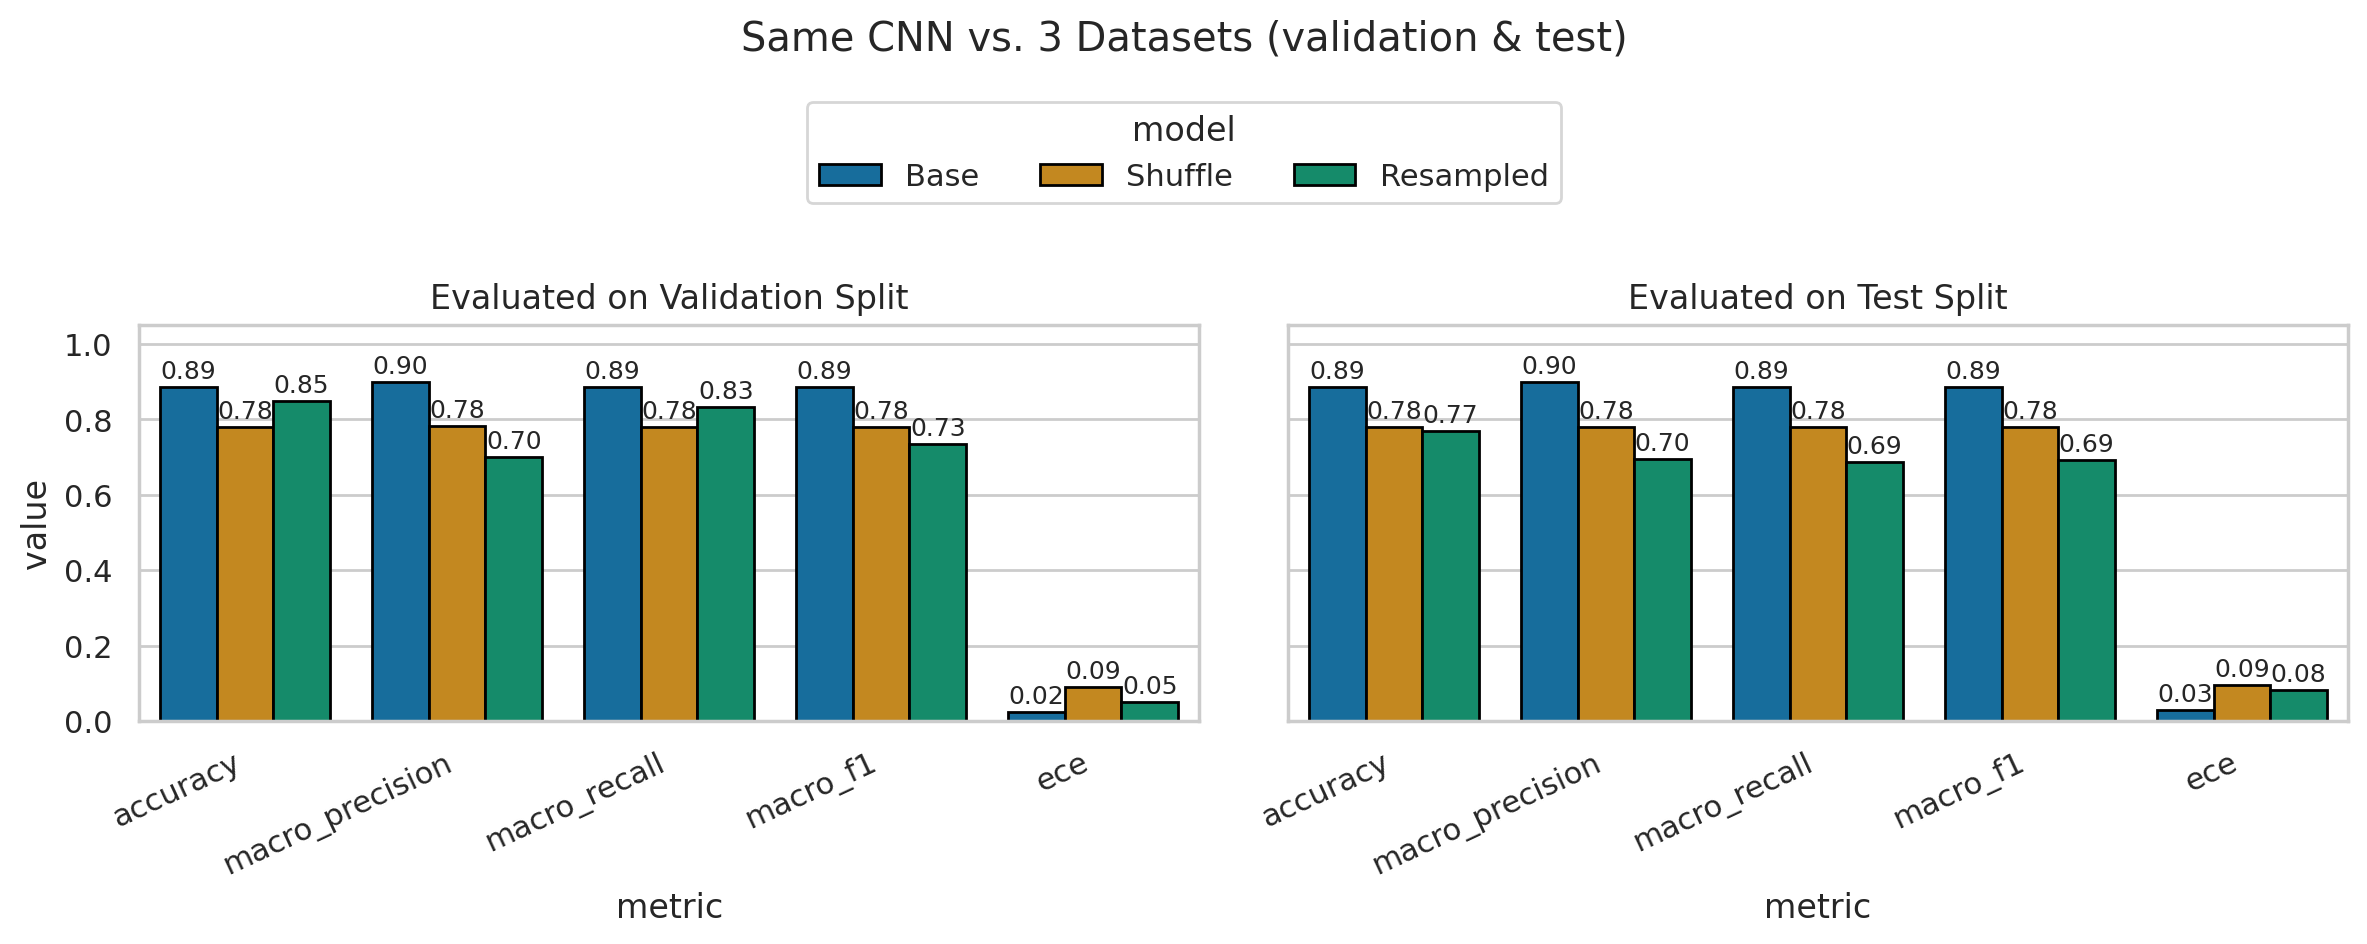

In [5]:
# Run evaluation on validation + test for the three time detectors
time_keys = ["time_base", "time_shuffle", "time_resampled"]
time_results = [evaluate_model(RUNS[k]["label"], RUNS[k]["ckpt"], RUNS[k]["temp"], RUNS[k]["data_root"]) for k in time_keys]
time_results_df = pd.concat(time_results, ignore_index=True)
plot_metric_table(time_results_df, title="Same CNN vs. 3 Datasets (validation & test)")

### Interpretation
- Pixel shuffling kills spatial cues but keeps global appearance. Photmetric experiment shows time-gap photometry remains a primary signal, so the control still scores well.
- Resampling reduces geographic/color skew but does not close it. The model exploits residual appearance bias, sometimes edging the resampled run.
- Takeaway: performance here reflects rather pre/post bias and phtometric bias, not structural damage detection.

In [6]:
# Grad-CAM helpers + single-image inference
def find_last_conv_layer(model: torch.nn.Module) -> torch.nn.Module:
    """Return the last Conv2d layer, which Grad-CAM uses as the target block."""
    target = None
    for module in model.modules():
        if isinstance(module, torch.nn.Conv2d):
            target = module
    if target is None:
        raise RuntimeError("No Conv2d layer found for Grad-CAM.")
    return target

def unnormalize(img_t: torch.Tensor, cfg: TrainConfig) -> np.ndarray:
    """Invert normalization back to RGB for plotting."""
    mean, std = torch.tensor(cfg.mean).view(3, 1, 1), torch.tensor(cfg.std).view(3, 1, 1)
    img = img_t.detach().cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

def grad_cam(model: torch.nn.Module, img_t: torch.Tensor, class_idx: int, cfg: TrainConfig, temperature: Optional[TemperatureScaler] = None):
    """Compute a Grad-CAM heatmap for a single image tensor."""
    model.zero_grad(set_to_none=True)
    target_layer = find_last_conv_layer(model)
    activations: List[torch.Tensor] = []
    gradients: List[torch.Tensor] = []

    def fwd_hook(_m, _inp, out):
        activations.append(out)

    def bwd_hook(_m, _gin, gout):
        gradients.append(gout[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    img_b = img_t.unsqueeze(0).to(device)
    img_b.requires_grad_(True)
    logits = model(img_b)
    logits = temperature(logits) if temperature is not None else logits
    probs = torch.softmax(logits, dim=1).detach().cpu().squeeze(0)
    logits[:, class_idx].sum().backward()

    h1.remove(); h2.remove()
    act, grad = activations[0].detach(), gradients[0].detach()
    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * act).sum(dim=1, keepdim=True))
    cam = torch.nn.functional.interpolate(cam, size=img_t.shape[1:], mode="bilinear", align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return cam, probs

def load_image_tensor(path: Path, cfg: TrainConfig) -> torch.Tensor:
    """Load and transform an image file using the stored eval transforms."""
    tfm = build_transforms(cfg, train=False)
    return tfm(Image.open(path).convert("RGB"))

def plot_cam_overlay(img_t: torch.Tensor, cam: np.ndarray, cfg: TrainConfig, title: str, ax: plt.Axes) -> None:
    """Overlay Grad-CAM heatmap on the unnormalized image."""
    ax.imshow(unnormalize(img_t, cfg))
    ax.imshow(cam, cmap="inferno", alpha=0.4)
    ax.set_title(title)
    ax.axis("off")

def find_sample_by_name(root: Path, filename: str, split: str = "test") -> Optional[Path]:
    """Find a file by name under the chosen split; returns None if missing."""
    candidates = list((root / split).rglob(filename))
    return candidates[0] if candidates else None

def run_single_inference(sample_path: Path, label: str, model: torch.nn.Module, cfg: TrainConfig, temperature: Optional[TemperatureScaler]):
    """Run one forward pass + Grad-CAM and return tensors plus a readable title."""
    img_t = load_image_tensor(sample_path, cfg)
    cam, probs = grad_cam(model, img_t, class_idx=0, cfg=cfg, temperature=temperature)
    prob_damage = float(probs[0])
    pred_label = "damage" if int(probs.argmax()) == 0 else "no_damage"
    title = f"{label}\nPred: {pred_label} (p_damage={prob_damage:.3f})"
    return img_t, cam, title

## 5. "Time Detector" Grad-CAMs
- Report Section 3.2.1: same CNN trained on original, pixel shuffled and resampled dataset shows background-focused vs. roof-focused heatmaps; expect similar patterns comparing Base/Shuffle/Resampled.
- If heat maps remain diffuse or hug roads/vegetation, the model is still using temporal or context shortcuts.

In [7]:
# Models reused for Grad-CAM and inference
loaded_models: Dict[str, Dict] = {}
for key in ["time_base", "time_shuffle", "time_resampled", "convnext_tiny_data", "resnet34_resampled", "resnet50_resampled", "resnet34_hp"]:
    spec = RUNS[key]
    model, cfg, temp = load_model_bundle(spec["label"], spec["ckpt"], spec["temp"], spec["data_root"])
    loaded_models[key] = {"label": spec["label"], "model": model, "cfg": cfg, "temp": temp}
    print(f"Loaded {spec['label']} from {spec['ckpt']}")


Loaded Base from /home/tim/test/ipeo-hurricane-damage-detection/artifacts/time_detector_base.pt
Loaded Shuffle from /home/tim/test/ipeo-hurricane-damage-detection/artifacts/time_detector_shuffle.pt
Loaded Resampled from /home/tim/test/ipeo-hurricane-damage-detection/artifacts/time_detector_resampled.pt
Loaded ConvNeXt-Tiny (original) from /home/tim/test/ipeo-hurricane-damage-detection/artifacts/convnext_tiny-data.pt
Loaded ResNet34 (resampled) from /home/tim/test/ipeo-hurricane-damage-detection/artifacts/resnet34-resampled.pt
Loaded ResNet50 (resampled) from /home/tim/test/ipeo-hurricane-damage-detection/artifacts/resnet50-resampled.pt
Loaded ResNet34 (hp-tuned) from /home/tim/test/ipeo-hurricane-damage-detection/artifacts/resnet34-hp-tuned.pt


Identical samples are passed through the models, trained on the 3 different datasets (Base, Shuffle, and Resampled trained). Diffuse or background-focused heatmaps indicate reliance on temporal or appearance shortcuts, tighter roof-focused maps suggest improved localization after resampling.

Samples: [PosixPath('/home/tim/test/ipeo-hurricane-damage-detection/data_resampled/test/damage/test_damage_-93.604913_30.794565000000002_ba5cd9.jpeg'), PosixPath('/home/tim/test/ipeo-hurricane-damage-detection/data_resampled/test/damage/test_damage_-93.750073_29.789076_2c0235.jpeg')]


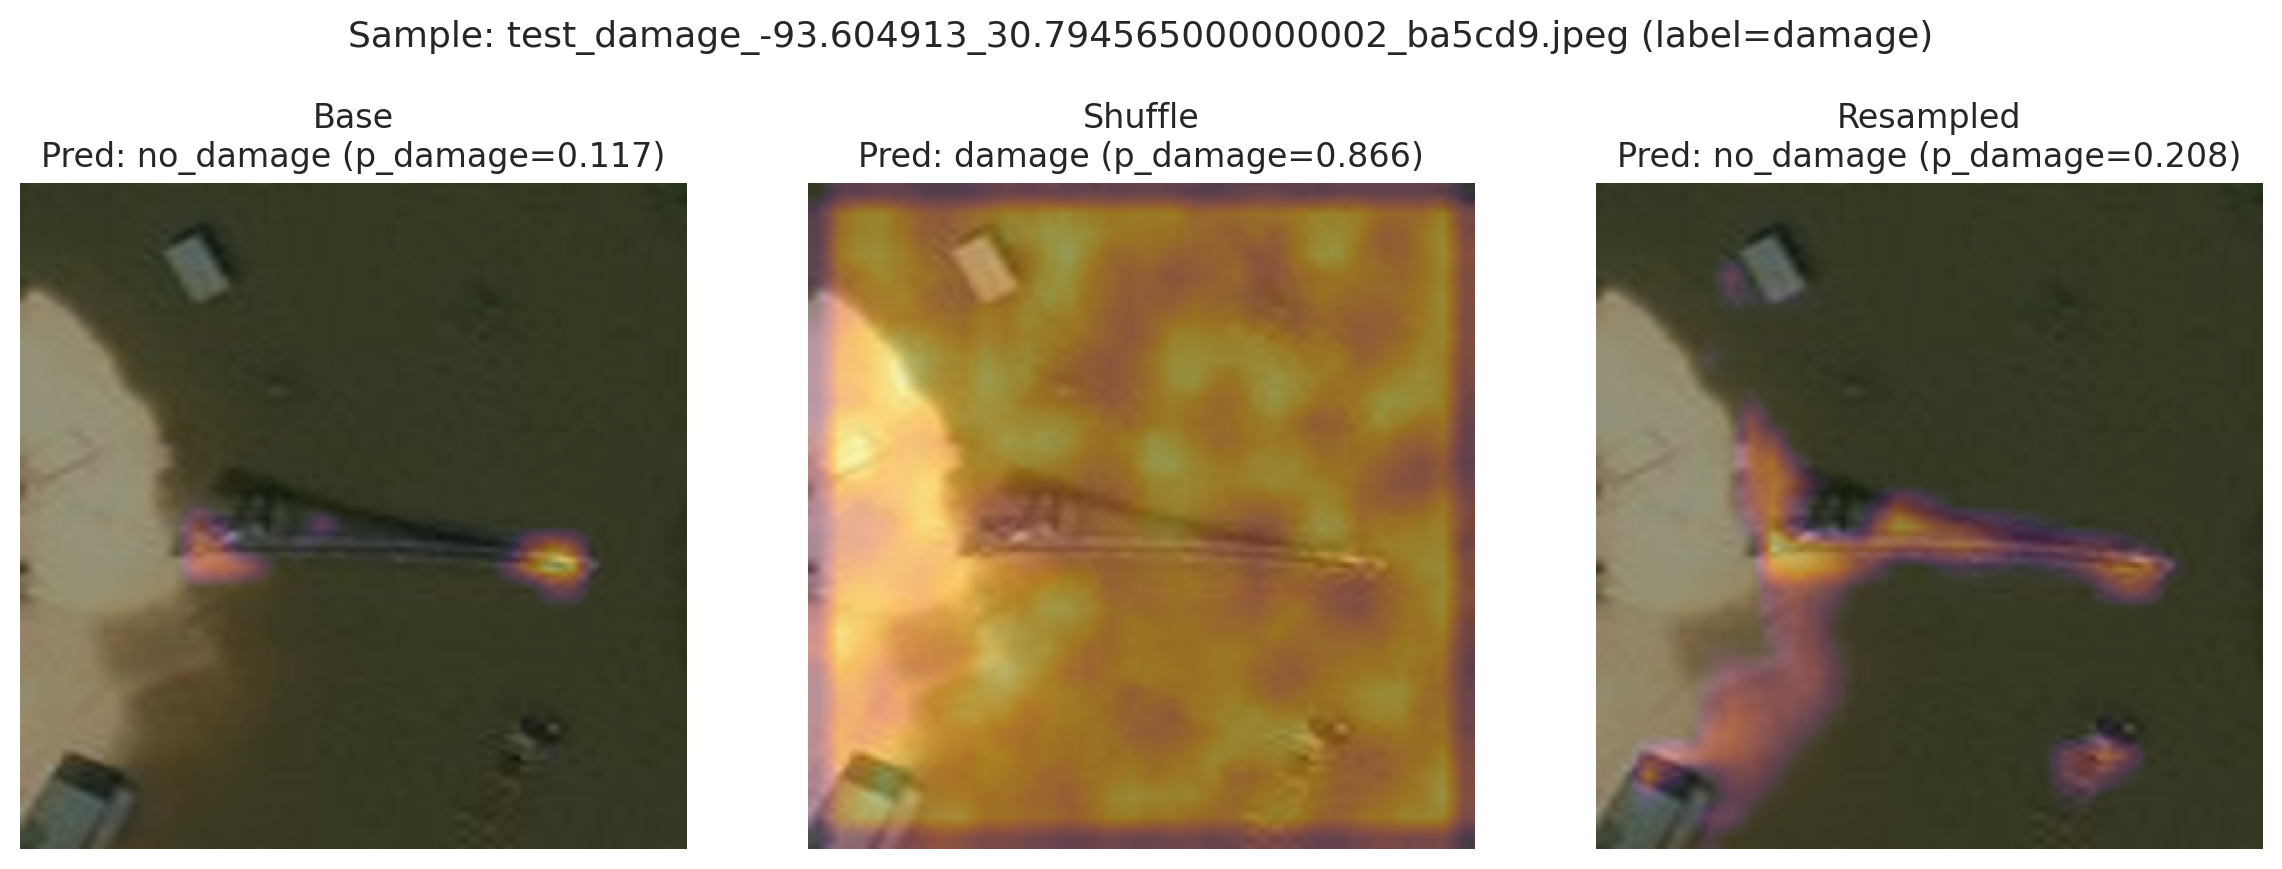

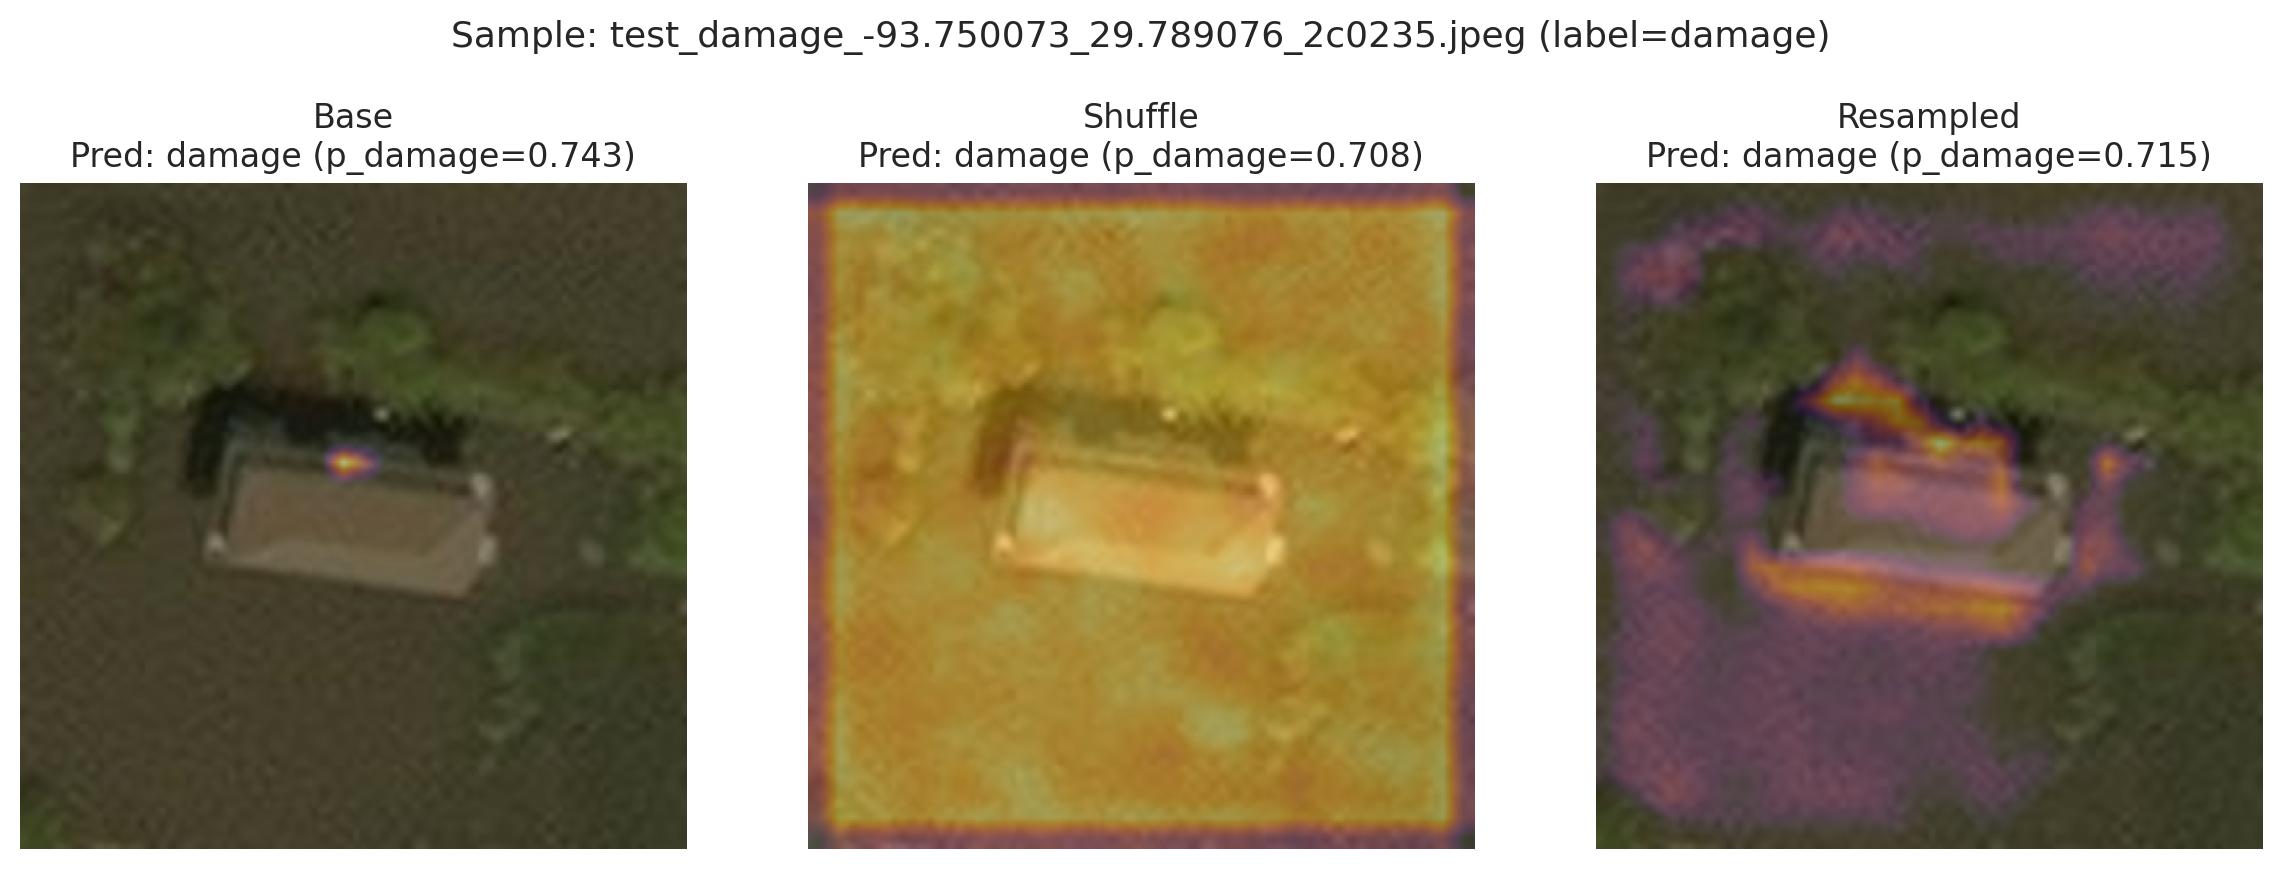

In [8]:
time_sample_names = [
"test_damage_-93.604913_30.794565000000002_ba5cd9.jpeg",
"test_damage_-93.750073_29.789076_2c0235.jpeg",
]
assert time_sample_names, "Set time_sample_names to existing filenames under data_resampled/test."
time_sample_paths = []
for name in time_sample_names:
    p = find_sample_by_name(RESAMPLED_ROOT, name, split="test")
    assert p is not None, f"Sample {name} not found under {RESAMPLED_ROOT}/test"
    time_sample_paths.append(p)
print("Samples:", time_sample_paths)
for sample in time_sample_paths:
    fig, axes = plt.subplots(1, 3, figsize=CAM_FIGSIZE_TRIPLE, dpi=PLOT_DPI)
    for ax, key in zip(axes, ["time_base", "time_shuffle", "time_resampled"]):
        bundle = loaded_models[key]
        img_t, cam, title = run_single_inference(sample, bundle["label"], bundle["model"], bundle["cfg"], bundle["temp"])
        plot_cam_overlay(img_t, cam, bundle["cfg"], title, ax)
    fig.suptitle(f"Sample: {sample.name} (label={sample.parent.name})", y=1.03, fontsize=13)
    plt.tight_layout(); plt.show()


Base and shuffle Grad CAMs stay diffuse and often sit on ground/background; resampled tightens slightly toward structures but still drifts off-roof when appearance cues dominate.

## 6. Grad-CAM: CNN Baselines (ConvNeXt/ResNet)

Using sample: /home/tim/test/ipeo-hurricane-damage-detection/data_resampled/test/damage/test_damage_-96.967457_28.815216999999997_b8d5c2.jpeg


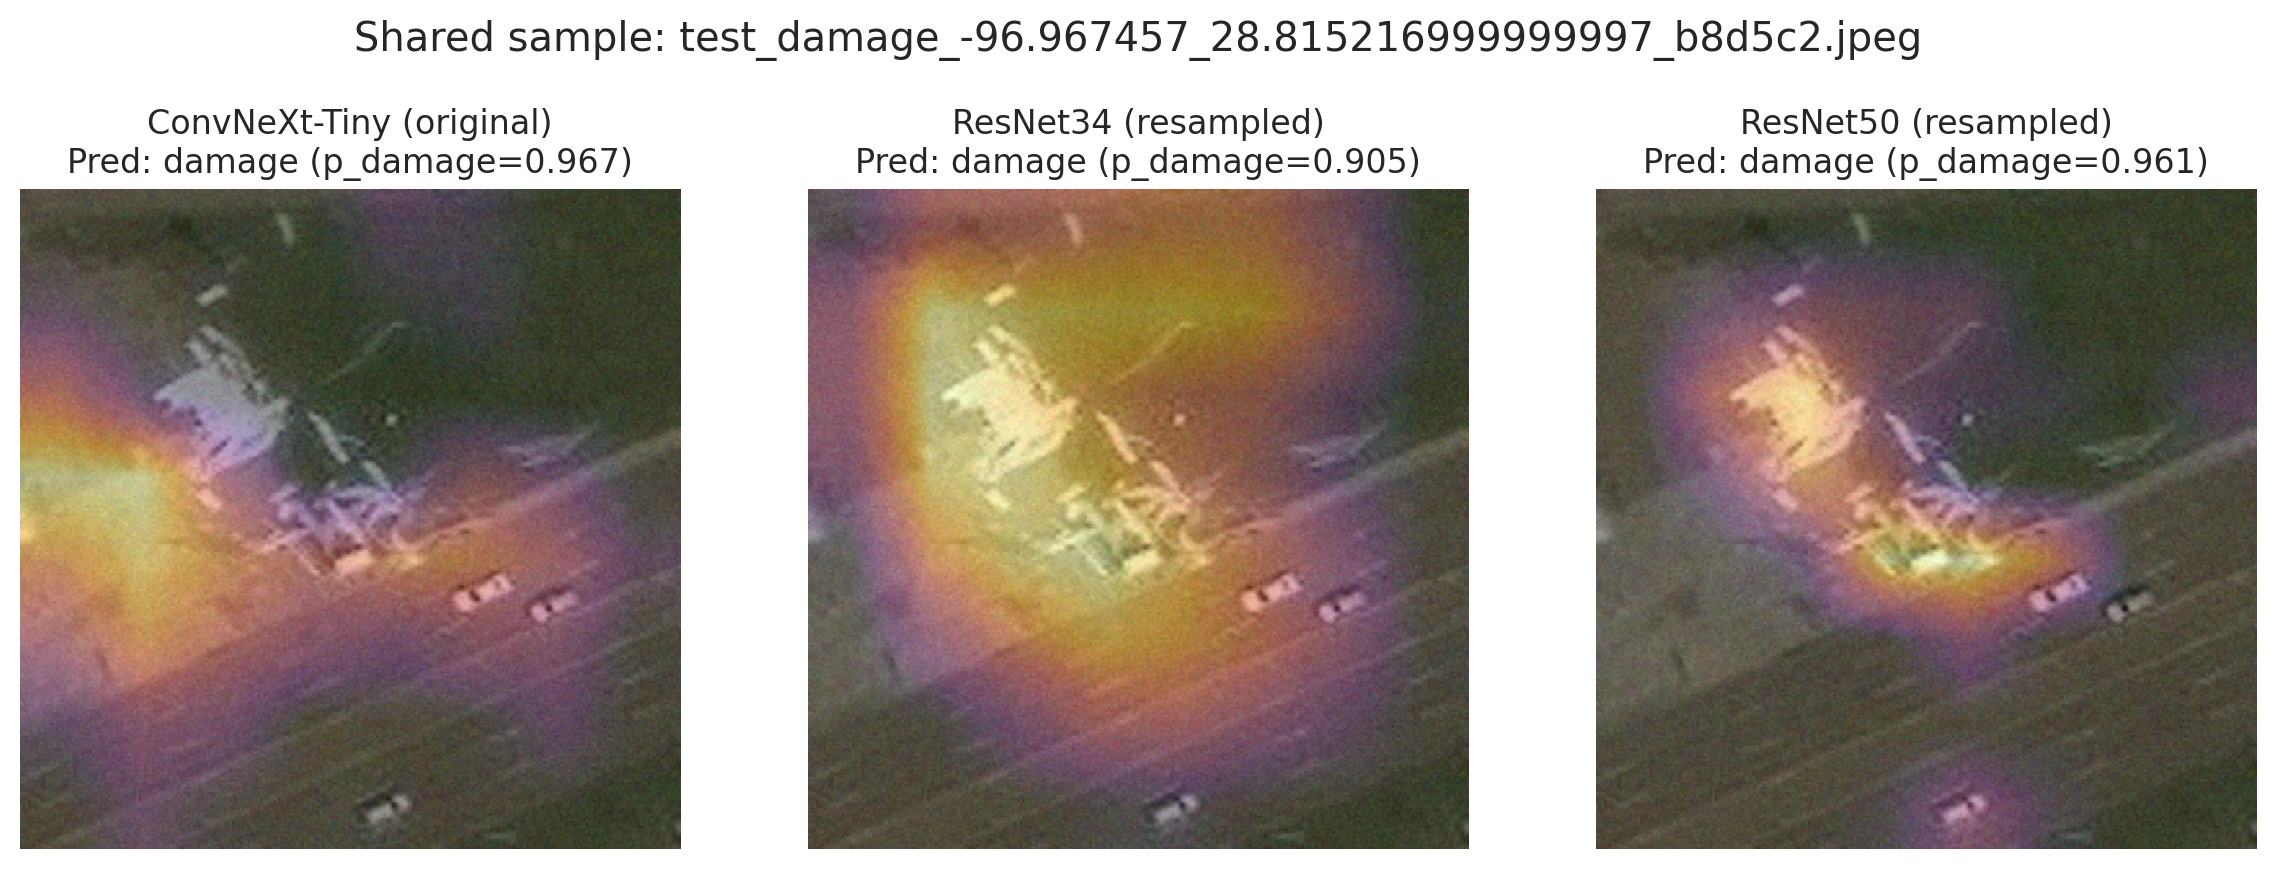

In [9]:
# Side-by-side Grad-CAM for ConvNeXt-Tiny (original) and ResNet34/50 (resampled) on the same sample
model_keys = ["convnext_tiny_data", "resnet34_resampled", "resnet50_resampled"]
sample_name = "test_damage_-96.967457_28.815216999999997_b8d5c2.jpeg"  # filename must exist under data_resampled/test
root_for_sample = RESAMPLED_ROOT
assert sample_name, "Set sample_name to a filename that exists under data_resampled/test."
sample_path = find_sample_by_name(root_for_sample, sample_name, split="test")
assert sample_path is not None, f"Sample {sample_name} not found under {root_for_sample}/test"
print("Using sample:", sample_path)

fig, axes = plt.subplots(1, 3, figsize=CAM_FIGSIZE_TRIPLE, dpi=PLOT_DPI)
for ax, key in zip(axes, model_keys):
    bundle = loaded_models[key]
    img_t, cam, title = run_single_inference(sample_path, bundle["label"], bundle["model"], bundle["cfg"], bundle["temp"])
    plot_cam_overlay(img_t, cam, bundle["cfg"], title, ax)
fig.suptitle(f"Shared sample: {sample_path.name}", y=1.03)
plt.tight_layout(); plt.show()


## 7. Hyperparameter-Tuned ResNet34 (resampled)

,model,split,accuracy,macro_precision,macro_recall,macro_f1,brier,ece
0,ResNet34 (hp-tuned),validation,0.9798,0.9519,0.9519,0.9519,0.0176,0.0188
1,ResNet34 (hp-tuned),test,0.9087,0.9252,0.8320,0.8659,0.0721,0.0393


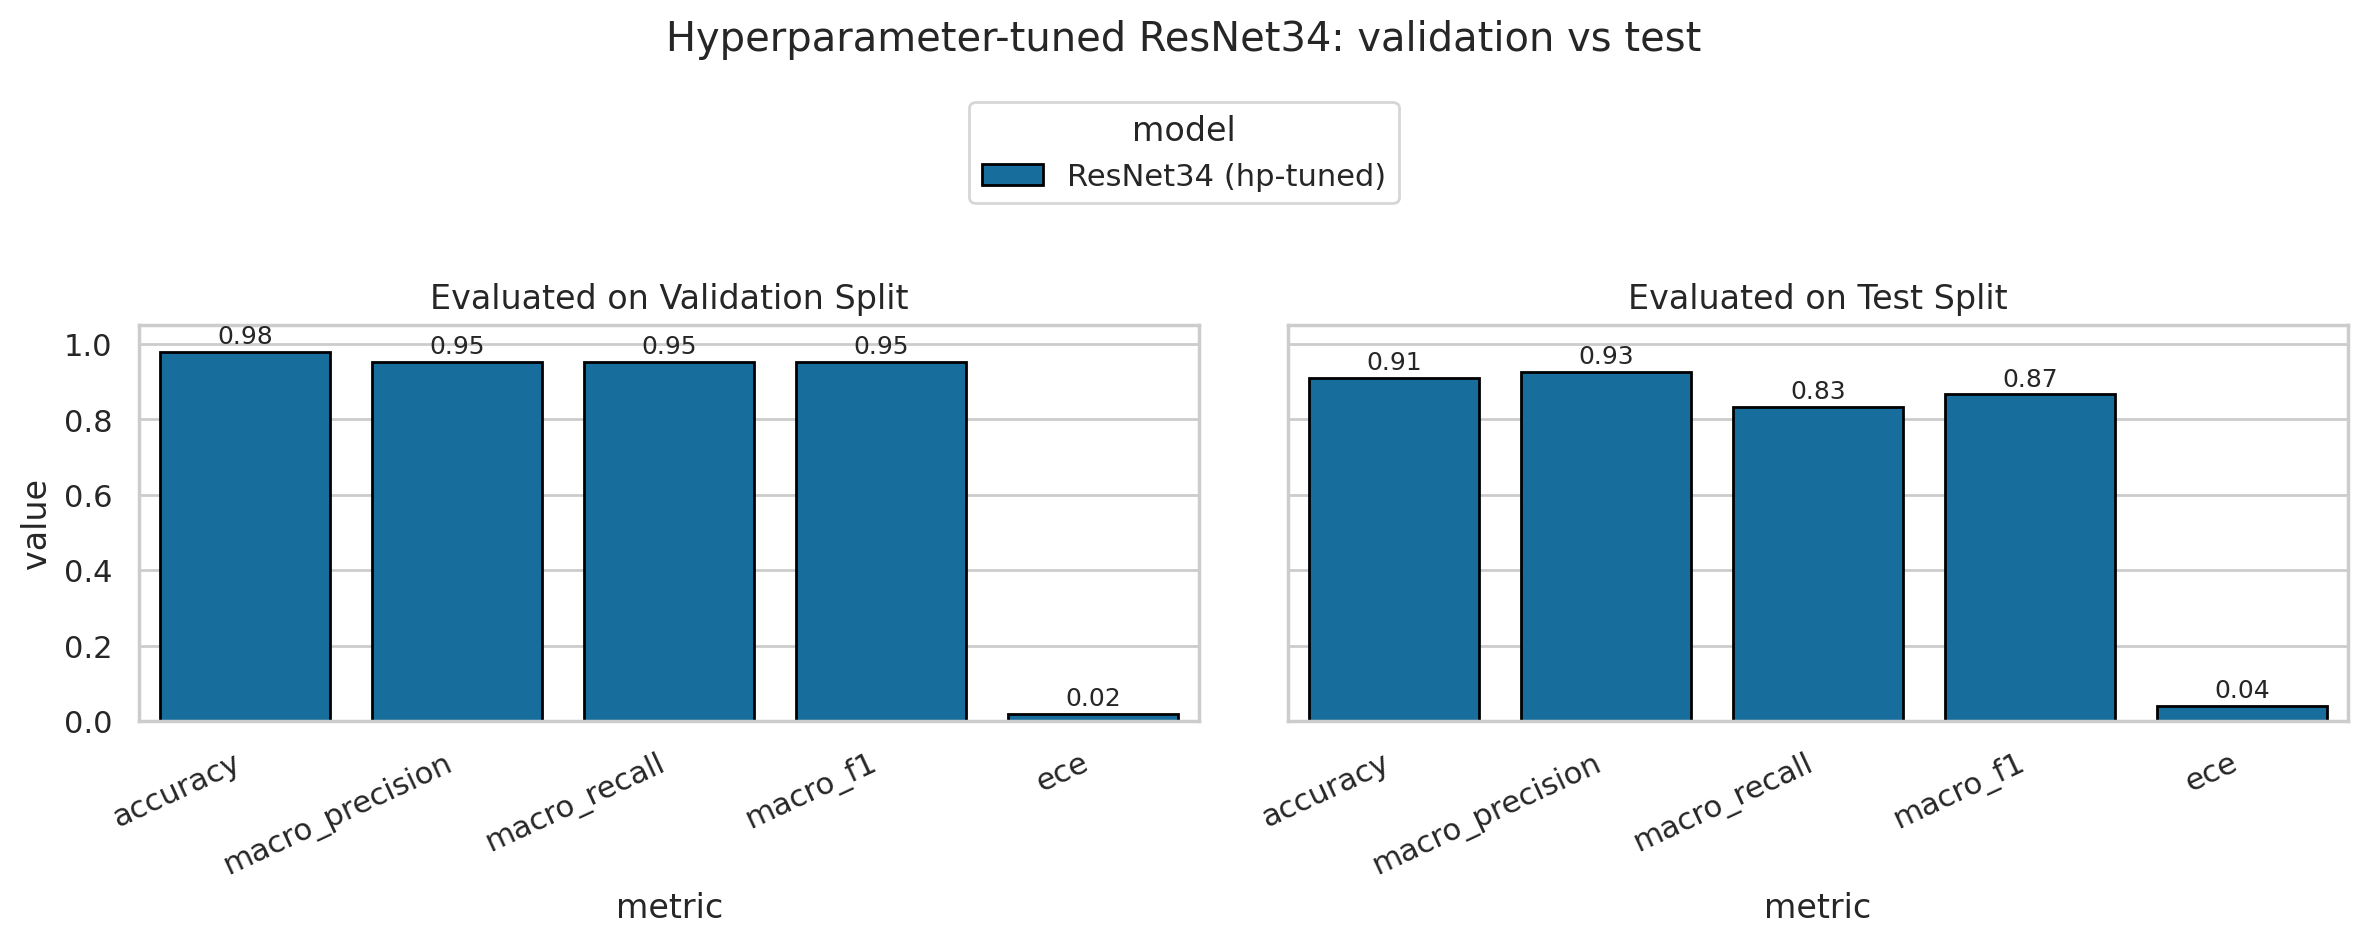

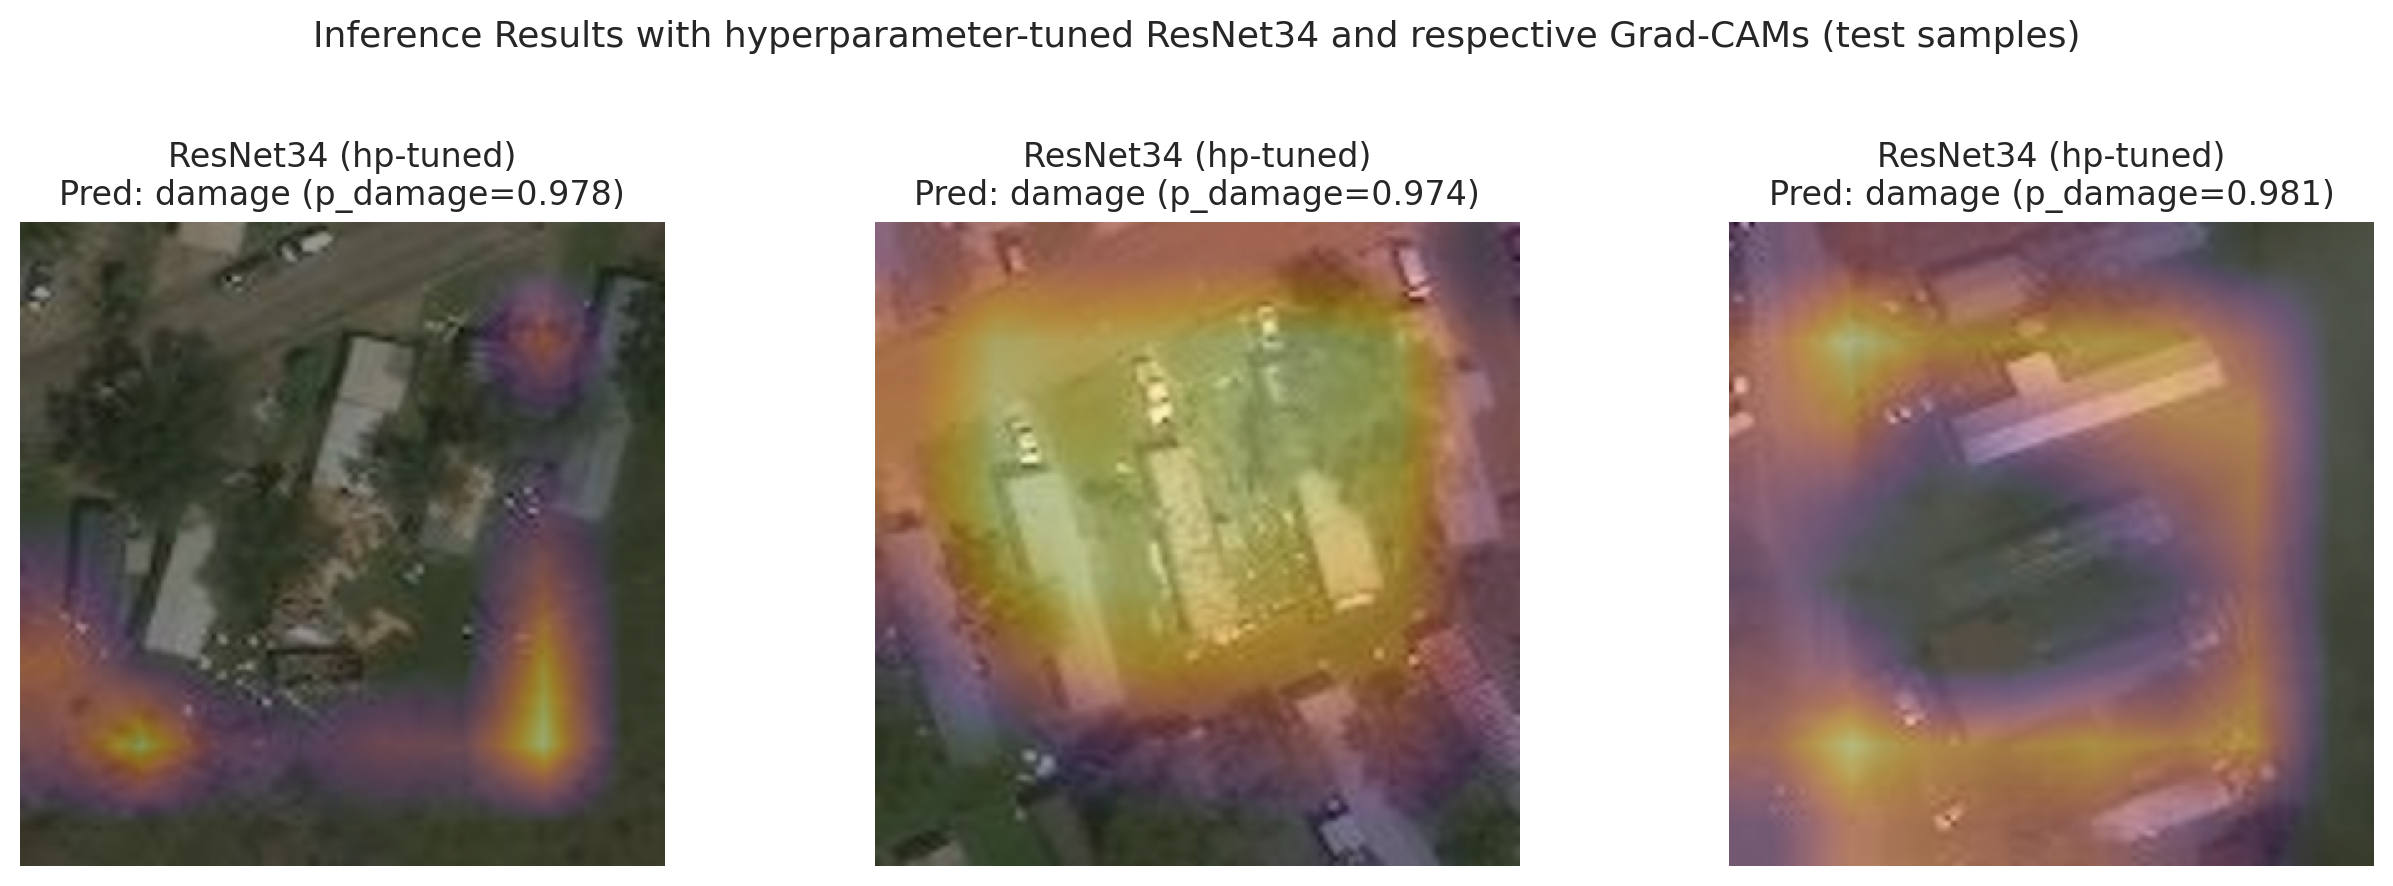

In [10]:
# Test evaluation + three-sample inference for the HP-tuned ResNet34
hp_spec = RUNS["resnet34_hp"]
hp_df = evaluate_model(hp_spec["label"], hp_spec["ckpt"], hp_spec["temp"], hp_spec["data_root"])
plot_metric_table(hp_df, title="Hyperparameter-tuned ResNet34: validation vs test")

hp_sample_names = [
    "test_damage_-96.98670600000001_28.784498_220b84.jpeg",
    "test_damage_-96.98536899999999_28.786592_27bc51.jpeg",
    "test_damage_-96.97719000000001_28.798614_95ca1c.jpeg",
]

assert hp_sample_names, "Provide filenames that exist under data_resampled/test."
hp_samples = []
for name in hp_sample_names:
    p = find_sample_by_name(RESAMPLED_ROOT, name, split="test")
    assert p is not None, f"Sample {name} not found under {RESAMPLED_ROOT}/test"
    hp_samples.append(p)

bundle = loaded_models["resnet34_hp"]
cams = []
for sample in hp_samples:
    img_t, cam, title = run_single_inference(sample, bundle["label"], bundle["model"], bundle["cfg"], bundle["temp"])
    short_title = f"{title}"
    cams.append((img_t, cam, short_title))

fig, axes = plt.subplots(1, len(cams), figsize=CAM_FIGSIZE_HP, dpi=PLOT_DPI)
if len(cams) == 1: axes = [axes]
for ax, (img_t, cam, ttl) in zip(axes, cams):
    plot_cam_overlay(img_t, cam, bundle["cfg"], ttl, ax)
fig.suptitle("Inference Results with hyperparameter-tuned ResNet34 and respective Grad-CAMs (test samples)", y=1.05, fontsize=13)
plt.tight_layout(); plt.show()